In [1]:
pip install pandas numpy scikit-learn matplotlib seaborn

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
movies = pd.read_csv("C://Users//PRAGYA//Downloads//archive (7)//movies.csv")
ratings = pd.read_csv("C://Users//PRAGYA//Downloads//archive (7)//ratings.csv")

movies.head()
ratings.head()

,userId,movieId,rating,timestamp
0,1,16,4.0,1217897793
1,1,24,1.5,1217895807
2,1,32,4.0,1217896246
3,1,47,4.0,1217896556
4,1,50,4.0,1217896523


In [7]:
movies.info()
ratings.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10329 entries, 0 to 10328
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   movieId  10329 non-null  int64 
 1   title    10329 non-null  object
 2   genres   10329 non-null  object
dtypes: int64(1), object(2)
memory usage: 242.2+ KB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 105339 entries, 0 to 105338
Data columns (total 4 columns):
 #   Column     Non-Null Count   Dtype  
---  ------     --------------   -----  
 0   userId     105339 non-null  int64  
 1   movieId    105339 non-null  int64  
 2   rating     105339 non-null  float64
 3   timestamp  105339 non-null  int64  
dtypes: float64(1), int64(3)
memory usage: 3.2 MB


In [9]:
ratings.groupby('movieId')['rating'].count().sort_values(ascending=False).head()

movieId
296    325
356    311
318    308
480    294
593    290
Name: rating, dtype: int64

In [11]:
movie_data = pd.merge(ratings, movies, on='movieId')
movie_data.head()

,userId,movieId,rating,timestamp,title,genres
0,1,16,4.0,1217897793,Casino (1995),Crime|Drama
1,1,24,1.5,1217895807,Powder (1995),Drama|Sci-Fi
2,1,32,4.0,1217896246,Twelve Monkeys (a.k.a. 12 Monkeys) (1995),Mystery|Sci-Fi|Thriller
3,1,47,4.0,1217896556,Seven (a.k.a. Se7en) (1995),Mystery|Thriller
4,1,50,4.0,1217896523,"Usual Suspects, The (1995)",Crime|Mystery|Thriller


In [13]:
ratings_mean = movie_data.groupby('title')['rating'].mean()
ratings_count = movie_data.groupby('title')['rating'].count()

ratings_df = pd.DataFrame({
    'average_rating': ratings_mean,
    'rating_count': ratings_count
})

ratings_df.head()

,average_rating,rating_count
title,,
'71 (2014),3.500,1
'Hellboy': The Seeds of Creation (2004),3.000,1
'Round Midnight (1986),2.500,1
'Til There Was You (1997),4.000,3
"'burbs, The (1989)",3.125,20


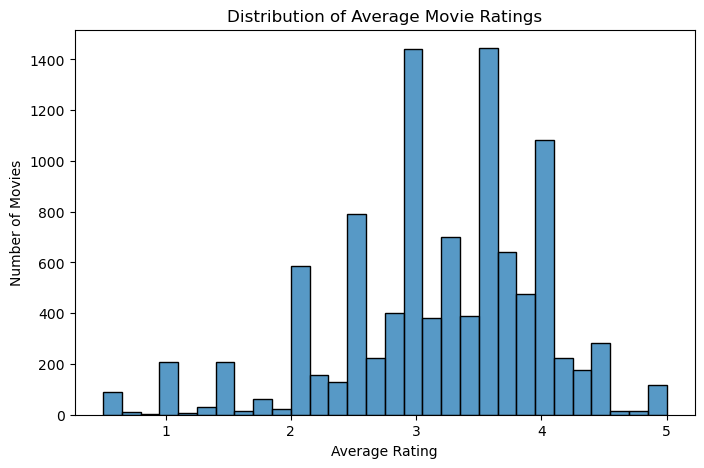

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,5))

sns.histplot(ratings_df['average_rating'], bins=30)

plt.title("Distribution of Average Movie Ratings")
plt.xlabel("Average Rating")
plt.ylabel("Number of Movies")
plt.show()

In [21]:
movie_matrix = movie_data.pivot_table(
    index='userId',
    columns='title',
    values='rating'
)
movie_matrix.head()

title,'71 (2014),'Hellboy': The Seeds of Creation (2004),'Round Midnight (1986),'Til There Was You (1997),"'burbs, The (1989)",'night Mother (1986),(500) Days of Summer (2009),*batteries not included (1987),...And Justice for All (1979),10 (1979),...,[REC] (2007),[REC]² (2009),[REC]³ 3 Génesis (2012),a/k/a Tommy Chong (2005),eXistenZ (1999),loudQUIETloud: A Film About the Pixies (2006),xXx (2002),xXx: State of the Union (2005),¡Three Amigos! (1986),À nous la liberté (Freedom for Us) (1931)
userId,,,,,,,,,,,,,,,,,,,,,
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [31]:
popular_movies = ratings_df[ratings_df['rating_count'] > 100].index
movie_matrix = movie_matrix[popular_movies]

In [33]:
movie_name = "Toy Story (1995)"
movie_ratings = movie_matrix[movie_name]
similar_movies = movie_matrix.corrwith(movie_ratings)
similar_movies = pd.DataFrame(similar_movies, columns=['correlation'])
similar_movies.dropna(inplace=True)
similar_movies = similar_movies.drop(movie_name)

In [35]:
similar_movies = pd.DataFrame(similar_movies, columns=['correlation'])
similar_movies.dropna(inplace=True)
similar_movies.head()

,correlation
title,
2001: A Space Odyssey (1968),0.149744
Ace Ventura: Pet Detective (1994),0.399721
Aladdin (1992),0.451327
Alien (1979),0.256509
Aliens (1986),0.260495


In [37]:
similar_movies = similar_movies.join(ratings_df['rating_count'])

In [39]:
recommendations = similar_movies[similar_movies['rating_count'] > 100].sort_values(
    'correlation', ascending=False
)

recommendations.head()

,correlation,rating_count
title,,
Toy Story 2 (1999),0.709677,104
Austin Powers: The Spy Who Shagged Me (1999),0.580651,117
Crimson Tide (1995),0.578642,107
Austin Powers: International Man of Mystery (1997),0.533061,101
"Bug's Life, A (1998)",0.506905,102


In [41]:
def recommend(movie_name):
    movie_ratings = movie_matrix[movie_name]
    similar_movies = movie_matrix.corrwith(movie_ratings)
    corr_df = pd.DataFrame(similar_movies, columns=['correlation'])
    corr_df.dropna(inplace=True)
    corr_df = corr_df.join(ratings_df['rating_count'])
    
    recommendations = corr_df[corr_df['rating_count'] > 100].sort_values(
        'correlation', ascending=False)
    
    return recommendations.head(10)

In [43]:
recommend("Toy Story (1995)")

,correlation,rating_count
title,,
Toy Story (1995),1.000000,232
Toy Story 2 (1999),0.709677,104
Austin Powers: The Spy Who Shagged Me (1999),0.580651,117
Crimson Tide (1995),0.578642,107
Austin Powers: International Man of Mystery (1997),0.533061,101
"Bug's Life, A (1998)",0.506905,102
Babe (1995),0.504718,129
Shakespeare in Love (1998),0.498968,106
Who Framed Roger Rabbit? (1988),0.498878,115
